# Bond Futures

A bond future is a standardised contract obligating delivery of a government bond on a specified future date at a price agreed today.

## Key concepts

### Delivery and conversion factor
At expiry the short side delivers one bond from an exchange-approved **basket**. Because basket bonds differ in coupon and maturity, each is assigned a **conversion factor (CF)** — the clean price per unit face value that a hypothetical bond with the same maturity but with a **6% notional yield** would have. The invoice price paid by the long is:

$$\text{Invoice price} = F \times CF + \text{Accrued interest}$$

### Theoretical (fair-value) futures price
No-arbitrage pricing via cost-of-carry:

$$F = \frac{(S + AI)(1 + r \cdot T) - \text{FV(coupons)}}{CF}$$

where $S$ is the bond's clean price, $AI$ is accrued interest, $r$ is the repo rate, $T$ is time to delivery, and $\text{FV(coupons)}$ is the future value of coupons paid between settlement and delivery.

### Cheapest-to-deliver (CTD)
The short side chooses which basket bond to deliver. They will deliver whichever bond minimises their net cost:

$$\text{CTD} = \arg\min_b \left( S_b - F \times CF_b \right)$$

### Implied repo rate
Given the observed futures price $F$, the **implied repo** is the financing rate that makes the no-arbitrage price equal to $F$. It measures how attractive carry-and-deliver is for each basket bond.

In [1]:
from neon.lib.fixed_income.bond import Bond
from neon.lib.fixed_income.bond_future import BondFuture
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print('All imports OK')

All imports OK


## Setup

Settlement date: 2025-01-01. Delivery date: 2025-04-01 (~3 months). Repo rate: 4%.

Basket of three 10-year bonds (same maturity, different coupons), each priced at YTM = 5%.

In [2]:
SETTLE        = '20250101'
DELIVERY_DATE = '20250401'
ISSUE         = '20250101'
MATURITY      = '20350101'
REPO_RATE     = 0.04
YTM           = 0.05

bfut = BondFuture(delivery_date=DELIVERY_DATE, repo_rate=REPO_RATE)

bond_a = Bond(issue_date=ISSUE, maturity_date=MATURITY, coupon_rate=0.03, coupon_freq=2, face=100.0)
bond_b = Bond(issue_date=ISSUE, maturity_date=MATURITY, coupon_rate=0.05, coupon_freq=2, face=100.0)
bond_c = Bond(issue_date=ISSUE, maturity_date=MATURITY, coupon_rate=0.07, coupon_freq=2, face=100.0)

basket = [bond_a, bond_b, bond_c]
labels = ['Bond A (3%)', 'Bond B (5%)', 'Bond C (7%)']

# Clean prices at YTM = 5%
clean_prices = {b: b.clean_price_from_ytm(SETTLE, YTM) for b in basket}

for label, bond in zip(labels, basket):
    print(f'{label}: clean price = {clean_prices[bond]:.4f}')

Bond A (3%): clean price = 84.4108
Bond B (5%): clean price = 100.0000
Bond C (7%): clean price = 115.5892


## 1. Conversion Factors

The conversion factor normalises each bond to a 6% notional yield. Bonds with a coupon below 6% have CF < 1; bonds above 6% have CF > 1.

In [3]:
print(f'{'Bond':<16} {'Coupon':>8} {'Clean price':>14} {'CF':>10}')
print('-' * 52)
for label, bond in zip(labels, basket):
    cf    = bfut.conversion_factor(bond, SETTLE)
    clean = clean_prices[bond]
    print(f'{label:<16} {bond._coupon_rate:>7.0%} {clean:>14.4f} {cf:>10.4f}')

Bond               Coupon    Clean price         CF
----------------------------------------------------
Bond A (3%)           3%        84.4108     0.7768
Bond B (5%)           5%       100.0000     0.9256
Bond C (7%)           7%       115.5892     1.0744


## 2. Theoretical Futures Price

The no-arbitrage futures price is derived from cost-of-carry. Each bond in the basket implies a different theoretical futures price because of differences in carry and coupon cash flows during the repo period.

In [4]:
print(f'{'Bond':<16} {'Clean price':>14} {'CF':>10} {'Theo futures':>14}')
print('-' * 58)
for label, bond in zip(labels, basket):
    cf    = bfut.conversion_factor(bond, SETTLE)
    clean = clean_prices[bond]
    theo  = bfut.theoretical_price(bond, SETTLE, clean)
    print(f'{label:<16} {clean:>14.4f} {cf:>10.4f} {theo:>14.4f}')

Bond                Clean price         CF   Theo futures
----------------------------------------------------------
Bond A (3%)             84.4108     0.7768       109.1630
Bond B (5%)            100.0000     0.9256       108.9522
Bond C (7%)            115.5892     1.0744       108.7987


## 3. Cheapest-to-Deliver (CTD)

The short selects the bond that minimises the net delivery cost: `clean_price - futures_price × CF`. The `BondFuture.ctd()` method computes this for the whole basket.

In [5]:
# Net delivery cost per bond (lower is cheaper for the short)
print(f'{'Bond':<16} {'Clean price':>14} {'Theo futures':>14} {'CF':>10} {'Net cost':>12}')
print('-' * 70)
for label, bond in zip(labels, basket):
    clean = clean_prices[bond]
    cf    = bfut.conversion_factor(bond, SETTLE)
    theo  = bfut.theoretical_price(bond, SETTLE, clean)
    net   = clean - theo * cf
    print(f'{label:<16} {clean:>14.4f} {theo:>14.4f} {cf:>10.4f} {net:>12.4f}')

ctd = bfut.ctd(basket, SETTLE, clean_prices)
ctd_label = labels[basket.index(ctd)]
print(f'\nCTD bond: {ctd_label}')

Bond                Clean price   Theo futures         CF     Net cost
----------------------------------------------------------------------
Bond A (3%)             84.4108       109.1630     0.7768      -0.3911
Bond B (5%)            100.0000       108.9522     0.9256      -0.8475
Bond C (7%)            115.5892       108.7987     1.0744      -1.3028

CTD bond: Bond C (7%)


## 4. Implied Repo Rate

The implied repo is the financing rate embedded in the observed futures price. When `futures_price = theoretical_price(repo)`, the implied repo equals the actual repo rate. In practice it is used to compare delivery alternatives: the bond with the **highest implied repo** is the CTD.

In [6]:
print(f'{'Bond':<16} {'Actual repo':>12} {'Implied repo':>14}')
print('-' * 44)
for label, bond in zip(labels, basket):
    clean      = clean_prices[bond]
    theo       = bfut.theoretical_price(bond, SETTLE, clean)
    # Pass the theoretical price as the observed futures price — should recover REPO_RATE
    impl_repo  = bfut.implied_repo(bond, SETTLE, clean, theo)
    print(f'{label:<16} {REPO_RATE:>11.4%} {impl_repo:>13.4%}')

print()
print('Note: implied repo ≈ actual repo when futures price equals theoretical price.')

Bond              Actual repo   Implied repo
--------------------------------------------
Bond A (3%)          4.0000%       4.0000%
Bond B (5%)          4.0000%       4.0000%


Bond C (7%)          4.0000%       4.0000%

Note: implied repo ≈ actual repo when futures price equals theoretical price.


## 5. Plot: Conversion Factor vs Coupon Rate

The conversion factor is a monotone function of coupon rate. When the notional yield (6%) equals the coupon rate, CF = 1. Higher coupons mean the bond is priced above the 6% benchmark → CF > 1; lower coupons → CF < 1.

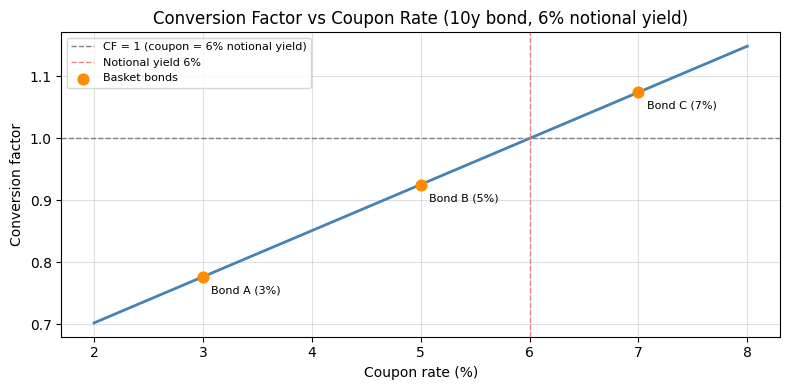

In [7]:
coupon_range = np.linspace(0.02, 0.08, 100)

cf_values = [
    bfut.conversion_factor(
        Bond(issue_date=ISSUE, maturity_date=MATURITY, coupon_rate=c, coupon_freq=2, face=100.0),
        SETTLE,
    )
    for c in coupon_range
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coupon_range * 100, cf_values, color='steelblue', linewidth=2)
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1, label='CF = 1 (coupon = 6% notional yield)')
ax.axvline(6.0, color='lightcoral', linestyle='--', linewidth=1, label='Notional yield 6%')

# Mark the three basket bonds
basket_coupons = [b._coupon_rate * 100 for b in basket]
basket_cfs     = [bfut.conversion_factor(b, SETTLE) for b in basket]
ax.scatter(basket_coupons, basket_cfs, color='darkorange', zorder=5, s=60, label='Basket bonds')
for label, cx, cy in zip(labels, basket_coupons, basket_cfs):
    ax.annotate(label, (cx, cy), textcoords='offset points', xytext=(6, -12), fontsize=8)

ax.set_xlabel('Coupon rate (%)')
ax.set_ylabel('Conversion factor')
ax.set_title('Conversion Factor vs Coupon Rate (10y bond, 6% notional yield)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Plot: Theoretical Futures Price vs Repo Rate

A higher repo rate increases the carry cost of holding the bond, so the theoretical futures price rises. The relationship is approximately linear over a narrow rate range.

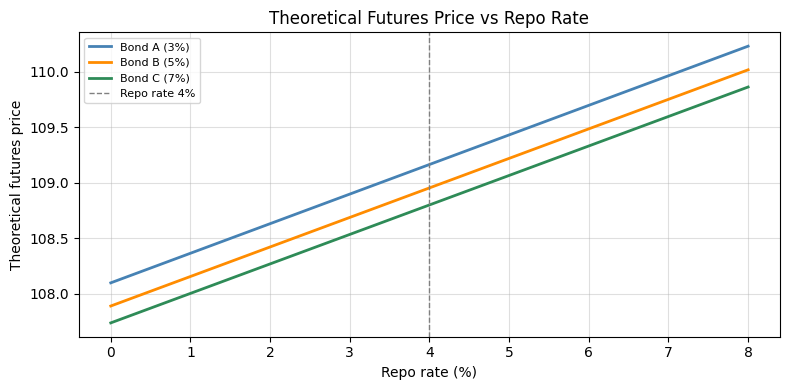

In [8]:
repo_range = np.linspace(0.00, 0.08, 100)

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['steelblue', 'darkorange', 'seagreen']
for bond, label, color in zip(basket, labels, colors):
    clean = clean_prices[bond]
    theo_prices = [
        BondFuture(delivery_date=DELIVERY_DATE, repo_rate=r).theoretical_price(bond, SETTLE, clean)
        for r in repo_range
    ]
    ax.plot(repo_range * 100, theo_prices, color=color, linewidth=2, label=label)

ax.axvline(REPO_RATE * 100, color='grey', linestyle='--', linewidth=1, label=f'Repo rate {REPO_RATE:.0%}')
ax.set_xlabel('Repo rate (%)')
ax.set_ylabel('Theoretical futures price')
ax.set_title('Theoretical Futures Price vs Repo Rate')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()